In [1]:
# import pandas as pd

# monday_df = pd.read_parquet("../DataSet/Benign-Monday-no-metadata.parquet")
# wednesday_df = pd.read_parquet("../DataSet/DoS-Wednesday-no-metadata.parquet")
# tuesday_df = pd.read_parquet("../DataSet/Bruteforce-Tuesday-no-metadata.parquet")
# thursday_df = pd.read_parquet("../DataSet/Infiltration-Thursday-no-metadata.parquet")
# friday_df = pd.read_parquet("../DataSet/Botnet-Friday-no-metadata.parquet")

import pandas as pd
from glob import glob
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np

!pip install boruta

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import entropy
from scipy.stats import zscore



files = glob("../DataSet/*.parquet")
dfs = [pd.read_parquet(f) for f in files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.count()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.1 MB/s eta 0:00:00


,0
Protocol,2313810
Flow Duration,2313810
Total Fwd Packets,2313810
Total Backward Packets,2313810
Fwd Packets Length Total,2313810
...,...
Idle Mean,2313810
Idle Std,2313810
Idle Max,2313810
Idle Min,2313810


In [2]:
# Convert them to all lowercase letters
# Replace spaces with underscores

df_all.columns = df_all.columns.str.replace(' ', '_').str.lower()

df_all.head(5)

,protocol,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,6,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.0,0,0,0.0,0.0,0,0,Benign
1,6,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.0,0,0,0.0,0.0,0,0,Benign
2,17,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.0,0,0,0.0,0.0,0,0,Benign
3,17,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.0,0,0,0.0,0.0,0,0,Benign
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.5,4822992,95,9463033.0,2657728.0,13600000,5700287,Benign


In [3]:
# Enforce numeric columns ONLY based on patterns
def enforce_numeric(df):
    patterns = ["count", "packet", "bytes", "length", "duration",
                "rate", "mean", "std", "max", "min"]

    for col in df.columns:
        if any(pat in col for pat in patterns):
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

df_all = enforce_numeric(df_all)

# only for sanity check

In [4]:
df_all = pd.get_dummies(df_all, columns=["protocol"], prefix="proto")

df_all.head(5)
# df_all['protocol'].nunique()

,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,...,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,proto_0,proto_6,proto_17
0,166,1,1,0,0,0,0,0.0,0.0,0,...,0,0,0.0,0.0,0,0,Benign,False,True,False
1,83,1,2,0,0,0,0,0.0,0.0,0,...,0,0,0.0,0.0,0,0,Benign,False,True,False
2,99947,1,1,48,48,48,48,48.0,0.0,48,...,0,0,0.0,0.0,0,0,Benign,False,False,True
3,37017,1,1,48,48,48,48,48.0,0.0,48,...,0,0,0.0,0.0,0,0,Benign,False,False,True
4,111161336,147,0,0,0,0,0,0.0,0.0,0,...,4822992,95,9463033.0,2657728.0,13600000,5700287,Benign,True,False,False


In [5]:
# limited the Benign to 250000 rows to make the other fields balanced so that model predicts correclty.
df_benign = df_all[df_all['label'] == "Benign"].sample(250000, random_state=42)
df_others = df_all[df_all['label'] != "Benign"]

df_balanced = pd.concat([df_benign, df_others])

# Shuffle after concatenation
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced.head(5)

,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,...,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,proto_0,proto_6,proto_17
0,150586,3,6,343,11595,343,0,114.333336,198.031143,7240,...,0,0,0.0,0.0,0,0,DoS Hulk,False,True,False
1,226,2,1,37,6,31,6,18.500000,17.677670,6,...,0,0,0.0,0.0,0,0,Benign,False,True,False
2,50435,3,6,26,11601,20,0,8.666667,10.263203,5840,...,0,0,0.0,0.0,0,0,DDoS,False,True,False
3,17714,2,2,12,11,6,6,6.000000,0.000000,11,...,0,0,0.0,0.0,0,0,DoS Hulk,False,True,False
4,5344396,7,5,347,165,219,0,49.571430,80.822556,165,...,0,0,0.0,0.0,0,0,Benign,False,True,False


In [6]:
# Find and handle null values

# Get the count of null values in each column
null_counts = df_balanced.isnull().sum()

# Print the total number of null entries in the dataset
print(f"Total null entries found: {null_counts.sum()}\n")

# Drop rows with any null values
df_balanced.dropna(inplace=True)

# Find and handle duplicates

# Get the count of duplicate rows
duplicate_count = df_balanced.duplicated().sum()

# # Print the number of duplicate entries found
print(f"Total duplicate entries found: {duplicate_count}\n")

# Remove duplicate rows from the dataset
df_balanced.drop_duplicates(inplace=True)

# Inform that duplicates have been removed
print("All duplicate entries have been removed.\n")

# Reset the index after dropping rows
df_balanced.reset_index(drop=True, inplace=True)

df_balanced.size

# Inspect categorical columns
categorical_columns = df_balanced.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_columns}\n")

# Display the first 5 rows of the cleaned dataset
df_balanced.head(20)

# Encode the attack labels into numeric format (e.g., Benign=0, DoS=1, Botnet=2, etc.)

le = LabelEncoder()
df_balanced['label_encoded'] = le.fit_transform(df_balanced['label'])

# Convert only numeric columns
numeric_cols = df_balanced.columns.drop(['label', 'label_encoded'])
df_balanced[numeric_cols] = df_balanced[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Remove invalid values
df_balanced = df_balanced.replace([np.inf, -np.inf], np.nan)
df_balanced.dropna(inplace=True)

Total null entries found: 0

Total duplicate entries found: 2072

All duplicate entries have been removed.

Categorical columns: ['label']



In [7]:
attack_data = df_balanced['label'].value_counts()
print(attack_data)

label
Benign                        247928
DoS Hulk                      172846
DDoS                          128014
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
PortScan                        1956
Web Attack � Brute Force        1470
Bot                             1437
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64


/tmp/ipython-input-471974909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_data.values, y=attack_data.index, palette="viridis")


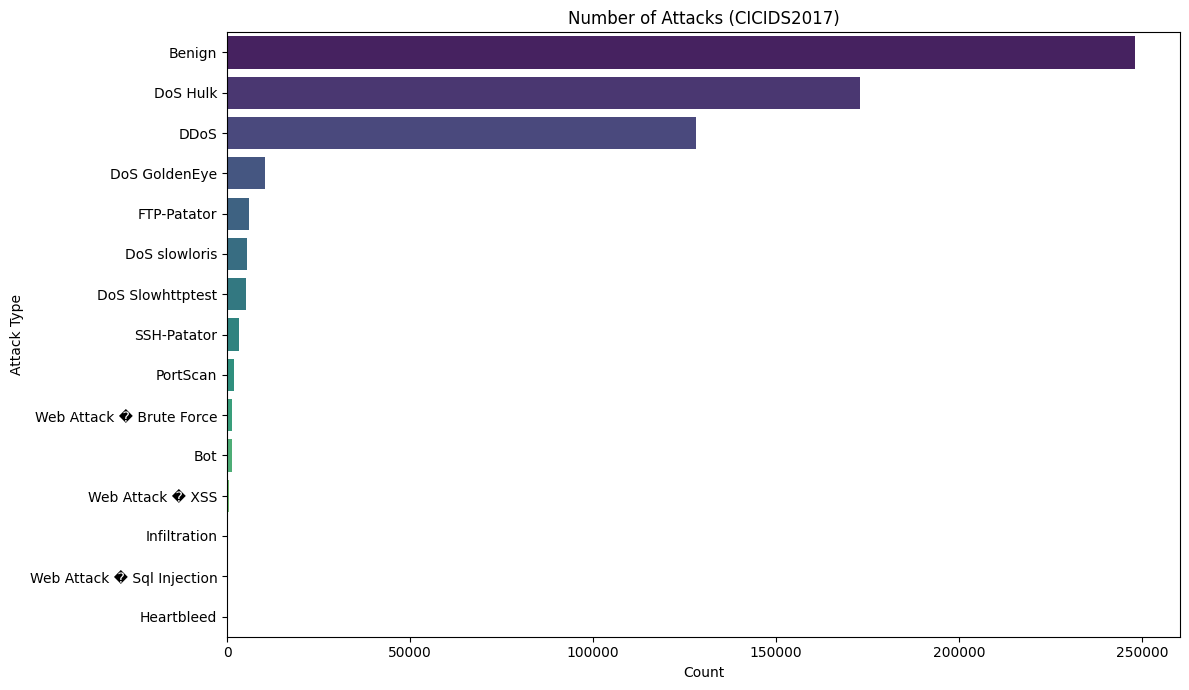

In [8]:
plt.figure(figsize=(12,7))
sns.barplot(x=attack_data.values, y=attack_data.index, palette="viridis")

plt.title("Number of Attacks (CICIDS2017)")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.show()

label
Benign                        42.422915
DoS Hulk                      29.575648
DDoS                          21.904452
DoS GoldenEye                  1.760036
FTP-Patator                    1.014852
DoS slowloris                  0.921426
DoS Slowhttptest               0.894562
SSH-Patator                    0.550803
PortScan                       0.334691
Web Attack � Brute Force       0.251531
Bot                            0.245885
Web Attack � XSS               0.111564
Infiltration                   0.006160
Web Attack � Sql Injection     0.003593
Heartbleed                     0.001882
Name: proportion, dtype: float64


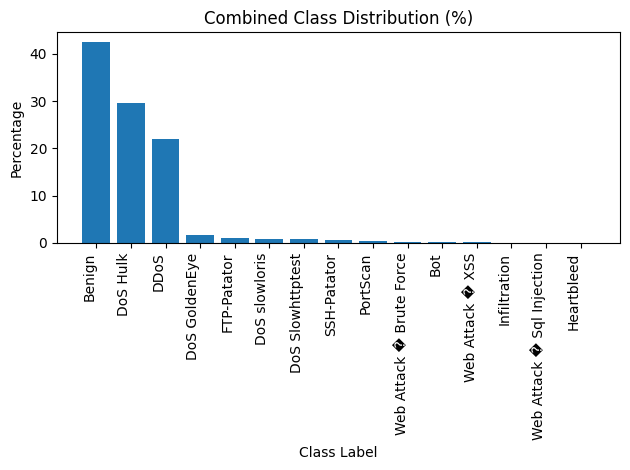

In [9]:
class_dist = df_balanced["label"].value_counts(normalize=True) * 100
print(class_dist)
plt.figure()
plt.bar(class_dist.index.astype(str), class_dist.values)
plt.title("Combined Class Distribution (%)")
plt.xlabel("Class Label")
plt.ylabel("Percentage")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

In [10]:


# Display value counts
print(df_balanced["label"].value_counts())

label
Benign                        247928
DoS Hulk                      172846
DDoS                          128014
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
PortScan                        1956
Web Attack � Brute Force        1470
Bot                             1437
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64


In [11]:
df_balanced.head(5)

,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,...,active_min,idle_mean,idle_std,idle_max,idle_min,label,proto_0,proto_6,proto_17,label_encoded
0,150586,3,6,343,11595,343,0,114.333336,198.031143,7240,...,0,0.0,0.0,0,0,DoS Hulk,False,True,False,4
1,226,2,1,37,6,31,6,18.500000,17.677670,6,...,0,0.0,0.0,0,0,Benign,False,True,False,0
2,50435,3,6,26,11601,20,0,8.666667,10.263203,5840,...,0,0.0,0.0,0,0,DDoS,False,True,False,2
3,17714,2,2,12,11,6,6,6.000000,0.000000,11,...,0,0.0,0.0,0,0,DoS Hulk,False,True,False,4
4,5344396,7,5,347,165,219,0,49.571430,80.822556,165,...,0,0.0,0.0,0,0,Benign,False,True,False,0


In [12]:
label_mapping = {i: label for i, label in enumerate(le.classes_)}
print(label_mapping)

{0: 'Benign', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator', 12: 'Web Attack � Brute Force', 13: 'Web Attack � Sql Injection', 14: 'Web Attack � XSS'}


In [13]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584420 entries, 0 to 584419
Data columns (total 81 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   flow_duration             584420 non-null  int32  
 1   total_fwd_packets         584420 non-null  int32  
 2   total_backward_packets    584420 non-null  int32  
 3   fwd_packets_length_total  584420 non-null  int32  
 4   bwd_packets_length_total  584420 non-null  int32  
 5   fwd_packet_length_max     584420 non-null  int16  
 6   fwd_packet_length_min     584420 non-null  int16  
 7   fwd_packet_length_mean    584420 non-null  float32
 8   fwd_packet_length_std     584420 non-null  float32
 9   bwd_packet_length_max     584420 non-null  int16  
 10  bwd_packet_length_min     584420 non-null  int16  
 11  bwd_packet_length_mean    584420 non-null  float32
 12  bwd_packet_length_std     584420 non-null  float32
 13  flow_bytes/s              584420 non-null  f

In [14]:
df_balanced['label'].value_counts()

,count
label,
Benign,247928
DoS Hulk,172846
DDoS,128014
DoS GoldenEye,10286
FTP-Patator,5931
DoS slowloris,5385
DoS Slowhttptest,5228
SSH-Patator,3219
PortScan,1956


In [15]:
# Feature engineering
# Raw features (like total packets, bytes, flow duration) are useful, but ratios, rates, and normalized features often provide better signals for anomaly detection
# We also need to handle zero or negative values to prevent errors during feature calculation or ML training.

eps = 1e-3  # small number to avoid division by zero
df_balanced['flow_duration'] = df_balanced['flow_duration'].clip(lower=eps)


In [16]:
# rate / ratio features
df_balanced['total_packets'] = df_balanced['total_fwd_packets'] + df_balanced['total_backward_packets'] + eps
df_balanced['total_bytes'] = df_balanced['fwd_packets_length_total'] + df_balanced['bwd_packets_length_total'] + eps


In [17]:
# packet_rate → packets per second (flow_duration is in microseconds, divide by 1e6).
# bytes_per_packet → average size of a packet.
# High packet rate or unusual bytes per packet are often indicators of attacks (DoS, scanning, bursty flows).

df_balanced['packet_rate'] = df_balanced['total_packets'] / (df_balanced['flow_duration'] / 1e6)
df_balanced['bytes_per_packet'] = df_balanced['total_bytes'] / df_balanced['total_packets']



In [18]:
# Coefficient of Variation (CV) features
#CV = standard deviation / mean → measures relative variability.
# idle and active CV can indicate irregular traffic patterns, useful for detecting attacks.

df_balanced['idle_mean_safe'] = df_balanced['idle_mean'].replace(0, eps)
df_balanced['active_mean_safe'] = df_balanced['active_mean'].replace(0, eps)

df_balanced['idle_cv'] = df_balanced['idle_std'] / df_balanced['idle_mean_safe']
df_balanced['active_cv'] = df_balanced['active_std'] / df_balanced['active_mean_safe']

# Drop temporary safe columns
df_balanced.drop(columns=['idle_mean_safe', 'active_mean_safe'], inplace=True)

In [19]:
# TCP Behavior Feature ML can learn TCP-specific behavior patterns
protocol_cols = [col for col in df_balanced.columns if col.startswith('proto_')]

if 'proto_6' in df_balanced.columns:
    df_balanced['tcp_behavior'] = df_balanced['proto_6'] * df_balanced['flow_duration']
else:
    df_balanced['tcp_behavior'] = 0


In [20]:
# Burst Ratio
# burst_ratio ≈ 1 → almost all packets are forward → could indicate DoS or bursty traffic.
# burst_ratio ≈ 0.5 → traffic is balanced forward/backward.

if 'fwd_packets/s' in df_balanced.columns and 'flow_packets/s' in df_balanced.columns:
    df_balanced['burst_ratio'] = df_balanced['fwd_packets/s'] / (df_balanced['flow_packets/s'] + 1e-5)
else:
    df_balanced['burst_ratio'] = 0

In [21]:
# Packet Entropy
# Malicious traffic often has different entropy patterns compared to normal traffic.
df_balanced['packet_entropy'] = df_balanced[['fwd_packet_length_std', 'bwd_packet_length_std']].apply(
    lambda x: entropy([x[0] + 1e-9, x[1] + 1e-9], base=2),  # Add epsilon to avoid log(0)
    axis=1
)


/tmp/ipython-input-3016118591.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: entropy([x[0] + 1e-9, x[1] + 1e-9], base=2),  # Add epsilon to avoid log(0)


In [22]:
# Attack traffic often has unusual flag patterns SYN floods, FIN scans
# Total flags in the flow
df_balanced['total_flag_count'] = df_balanced[['fin_flag_count','syn_flag_count','rst_flag_count',
                                               'psh_flag_count','ack_flag_count','urg_flag_count',
                                               'cwe_flag_count','ece_flag_count']].sum(axis=1)

# SYN/FIN ratio → scanning or SYN flood
df_balanced['syn_fin_ratio'] = (df_balanced['syn_flag_count'] + 1e-5) / (df_balanced['fin_flag_count'] + 1e-5)

# PSH/ACK ratio → bursty traffic indicator
df_balanced['psh_ack_ratio'] = (df_balanced['psh_flag_count'] + 1e-5) / (df_balanced['ack_flag_count'] + 1e-5)


In [23]:
# Attack traffic can have unusual segment size distributions.
df_balanced['segment_ratio'] = (df_balanced['avg_fwd_segment_size'] + 1e-5) / (df_balanced['avg_bwd_segment_size'] + 1e-5)


In [24]:
# Captures variability of packet timing. Bursty attacks often have high CV.
df_balanced['fwd_iat_cv'] = (df_balanced['fwd_iat_std'] + 1e-5) / (df_balanced['fwd_iat_mean'] + 1e-5)
df_balanced['bwd_iat_cv'] = (df_balanced['bwd_iat_std'] + 1e-5) / (df_balanced['bwd_iat_mean'] + 1e-5)


In [25]:
# Skewed packet length distributions are often attack indicators.
df_balanced['fwd_packet_skew'] = (df_balanced['fwd_packet_length_mean'] - df_balanced['fwd_packet_length_min']) / (df_balanced['fwd_packet_length_std'] + 1e-5)
df_balanced['bwd_packet_skew'] = (df_balanced['bwd_packet_length_mean'] - df_balanced['bwd_packet_length_min']) / (df_balanced['bwd_packet_length_std'] + 1e-5)


In [26]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584420 entries, 0 to 584419
Data columns (total 98 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   flow_duration             584420 non-null  float64
 1   total_fwd_packets         584420 non-null  int32  
 2   total_backward_packets    584420 non-null  int32  
 3   fwd_packets_length_total  584420 non-null  int32  
 4   bwd_packets_length_total  584420 non-null  int32  
 5   fwd_packet_length_max     584420 non-null  int16  
 6   fwd_packet_length_min     584420 non-null  int16  
 7   fwd_packet_length_mean    584420 non-null  float32
 8   fwd_packet_length_std     584420 non-null  float32
 9   bwd_packet_length_max     584420 non-null  int16  
 10  bwd_packet_length_min     584420 non-null  int16  
 11  bwd_packet_length_mean    584420 non-null  float32
 12  bwd_packet_length_std     584420 non-null  float32
 13  flow_bytes/s              584420 non-null  f

In [27]:
# Advanced Feature Engineering
# # Binary flag indicating whether the flow's duration is considered statistically abnormal.
# useful for detecting unusually short or long-lived flows that may be associated with network attacks or misbehavior.
# Step 1: Calculate z-score across all flows
# log-transform duration to reduce skew (common in network traffic)
df_balanced['log_flow_duration'] = np.log1p(df_balanced['flow_duration'])

# Step 2: Compute z-score for log flow duration
df_balanced['flow_duration_zscore'] = zscore(df_balanced['log_flow_duration'])

# Step 3: Flag abnormal flows (e.g., abs(z-score) > 3)
threshold = 3  # You can tune this threshold based on your inspection
df_balanced['abnormal_flow_duration'] = (np.abs(df_balanced['flow_duration_zscore']) > threshold).astype(int)

# Step 4: Drop intermediate columns to keep only the binary flag
df_balanced = df_balanced.drop(['log_flow_duration', 'flow_duration_zscore'], axis=1)

In [28]:
# Calculate activity (active/idle period) ratio for each flow
df_balanced['activity_period_ratio'] = (df_balanced['active_mean'] + eps) / (df_balanced['idle_mean'] + eps)

In [29]:
# Use existing proto_* columns and flow duration to normalize flag count per protocol
proto_cols = [col for col in df_balanced.columns if col.startswith('proto_')]
for proto in proto_cols:
    df_balanced[f"{proto}_flag_rate"] = df_balanced['total_flag_count'] * df_balanced[proto] / (df_balanced['flow_duration']/1e6 + 1e-5)
df_balanced.head(5)
#df_balanced = df_balanced.drop(['proto_0_flag_rate_flag_rate', 'proto_6_flag_rate_flag_rate', 'proto_17_flag_rate_flag_rate'], axis=1)

,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,...,segment_ratio,fwd_iat_cv,bwd_iat_cv,fwd_packet_skew,bwd_packet_skew,abnormal_flow_duration,activity_period_ratio,proto_0_flag_rate,proto_6_flag_rate,proto_17_flag_rate
0,150586.0,3,6,343,11595,343,0,114.333336,198.031143,7240,...,0.059163,6.396166e-01,1.963709e+00,0.577350,0.716899,0,1.0,0.0,6.640283,0.0
1,226.0,2,1,37,6,31,6,18.500000,17.677670,6,...,3.083330,4.424778e-08,1.000000e+00,0.707106,0.000000,0,1.0,0.0,8474.576271,0.0
2,50435.0,3,6,26,11601,20,0,8.666667,10.263203,5840,...,0.004482,1.392976e+00,1.915098e+00,0.844440,0.878433,0,1.0,0.0,19.823570,0.0
3,17714.0,2,2,12,11,6,6,6.000000,0.000000,11,...,1.090909,2.197802e-08,5.664438e-10,0.000000,0.707106,0,1.0,0.0,56.420673,0.0
4,5344396.0,7,5,347,165,219,0,49.571430,80.822556,165,...,1.502164,1.782504e+00,1.493691e+00,0.613337,0.447214,0,1.0,0.0,0.187112,0.0


In [30]:
df_balanced['flag_change_rate'] = df_balanced['total_flag_count'] / ((df_balanced['flow_duration'] / 1e6) + eps)
anomaly_feats = ['burst_ratio', 'active_cv', 'flag_change_rate']  # Check these really exist!
for col in anomaly_feats:
    df_balanced[col + "_scaled"] = MinMaxScaler().fit_transform(df_balanced[[col]])

df_balanced['flow_anomaly_index'] = df_balanced[[c + "_scaled" for c in anomaly_feats]].sum(axis=1)
# Step 4: Drop intermediate columns to keep only the binary flag
df_balanced = df_balanced.drop(['burst_ratio_scaled', 'active_cv_scaled','flag_change_rate_scaled'], axis=1)
df_balanced.head(5)

,flow_duration,total_fwd_packets,total_backward_packets,fwd_packets_length_total,bwd_packets_length_total,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,...,bwd_iat_cv,fwd_packet_skew,bwd_packet_skew,abnormal_flow_duration,activity_period_ratio,proto_0_flag_rate,proto_6_flag_rate,proto_17_flag_rate,flag_change_rate,flow_anomaly_index
0,150586.0,3,6,343,11595,343,0,114.333336,198.031143,7240,...,1.963709e+00,0.577350,0.716899,0,1.0,0.0,6.640283,0.0,6.596915,0.334984
1,226.0,2,1,37,6,31,6,18.500000,17.677670,6,...,1.000000e+00,0.707106,0.000000,0,1.0,0.0,8474.576271,0.0,1631.321370,1.074905
2,50435.0,3,6,26,11601,20,0,8.666667,10.263203,5840,...,1.915098e+00,0.844440,0.878433,0,1.0,0.0,19.823570,0.0,19.442014,0.338199
3,17714.0,2,2,12,11,6,6,6.000000,0.000000,11,...,5.664438e-10,0.000000,0.707106,0,1.0,0.0,56.420673,0.0,53.435930,0.513372
4,5344396.0,7,5,347,165,219,0,49.571430,80.822556,165,...,1.493691e+00,0.613337,0.447214,0,1.0,0.0,0.187112,0.0,0.187077,0.583378


In [31]:
# For each flow, using cumulative expanding mean/std for packet size or IAT, entire DataFrame:
df_balanced['exp_packet_size_mean'] = df_balanced['bytes_per_packet'].expanding().mean()
df_balanced['exp_packet_size_std'] = df_balanced['bytes_per_packet'].expanding().std()

# For IAT (forward direction)
df_balanced['exp_fwd_iat_mean'] = df_balanced['fwd_iat_mean'].expanding().mean()
df_balanced['exp_fwd_iat_std'] = df_balanced['fwd_iat_mean'].expanding().std()


In [32]:
# before feature selction or extraction do split and scale it so there is no imbalance.
X = df_balanced.drop(['label', 'label_encoded'], axis=1)
y = df_balanced['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
X_train_scaled[:1]

array([[-7.65691915e-01, -1.36017553e-02, -1.07273253e-02,
        -5.48284616e-02, -8.34758468e-03, -2.76697478e-01,
         9.82197463e-01,  2.52806720e-02, -3.52381578e-01,
        -8.08187688e-01,  2.74368959e+00, -7.48366675e-01,
        -8.13439798e-01, -4.33235776e-02, -1.14856926e-01,
        -5.31582072e-01, -7.11785845e-01, -7.16542353e-01,
        -6.01557721e-02, -7.56297170e-01, -5.45374926e-01,
        -6.82107673e-01, -7.11416270e-01, -1.18001362e-01,
        -4.12928728e-01, -2.79794334e-01, -3.41930345e-01,
        -3.65914813e-01, -1.10315127e-01, -1.60237718e-01,
         0.00000000e+00, -2.92498959e-03,  0.00000000e+00,
         2.71683609e-03,  1.65640768e-03, -1.00293234e-01,
        -1.00234744e-01,  2.18805587e+00, -8.23527644e-01,
        -7.55693994e-01, -8.08830294e-01, -6.42551971e-01,
        -3.40740491e-01, -1.60237718e-01, -1.21492387e-02,
        -6.32595678e-01, -8.30201069e-01, -2.20496053e-01,
        -2.92498959e-03, -1.21492387e-02,  5.45541712e-0

In [35]:
#Feature Selection
# Prepare feature names
feature_names = X_train.columns

print("Total features:", len(feature_names))
feature_names[:10]

Total features: 107


Index(['flow_duration', 'total_fwd_packets', 'total_backward_packets',
       'fwd_packets_length_total', 'bwd_packets_length_total',
       'fwd_packet_length_max', 'fwd_packet_length_min',
       'fwd_packet_length_mean', 'fwd_packet_length_std',
       'bwd_packet_length_max'],
      dtype='object')

In [36]:
#Remove highly correlated features
corr_matrix = X_train.corr().abs()

# Upper-triangle mask
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns to drop
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print("Highly correlated features to drop:")
print(to_drop_corr)

Highly correlated features to drop:
['total_backward_packets', 'bwd_packets_length_total', 'fwd_packet_length_std', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_iat_max', 'fwd_iat_total', 'fwd_iat_std', 'fwd_iat_max', 'fwd_packets/s', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'syn_flag_count', 'cwe_flag_count', 'ece_flag_count', 'avg_packet_size', 'avg_fwd_segment_size', 'avg_bwd_segment_size', 'subflow_fwd_packets', 'subflow_fwd_bytes', 'subflow_bwd_packets', 'subflow_bwd_bytes', 'fwd_seg_size_min', 'idle_mean', 'idle_max', 'idle_min', 'proto_17', 'total_packets', 'total_bytes', 'bytes_per_packet', 'idle_cv', 'tcp_behavior', 'syn_fin_ratio', 'psh_ack_ratio']


In [37]:
# Impute missing values in X_train_scaled

imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.fit_transform(X_test_scaled)
# Now run SelectKBest on the imputed data
selector_anova = SelectKBest(score_func=f_classif, k=30)
selector_anova.fit(X_train_imputed, y_train)

anova_scores = pd.DataFrame({
    'feature': feature_names,
    'score': selector_anova.scores_
}).sort_values(by='score', ascending=False)

anova_scores.head(20)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 30  32  54  55  56  57  58  59  96  98 100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,feature,score
75,idle_min,50540.065767
21,fwd_iat_std,50424.585472
72,idle_mean,49804.747489
74,idle_max,44675.544711
17,flow_iat_max,43992.215545
22,fwd_iat_max,43974.545556
53,avg_bwd_segment_size,36527.296100
11,bwd_packet_length_mean,36527.296100
16,flow_iat_std,34283.732862
9,bwd_packet_length_max,30984.011064


In [38]:
# Use the imputed X_train
selector_mi = SelectKBest(score_func=mutual_info_classif, k=30)
selector_mi.fit(X_train_imputed, y_train)

# Collect feature scores
mi_scores = pd.DataFrame({
    'feature': feature_names,
    'score': selector_mi.scores_
}).sort_values(by='score', ascending=False)

# Display top 20 features according to mutual information
print("Top Mutual Information features:")
mi_scores.head(20)

Top Mutual Information features:


,feature,score
82,bytes_per_packet,1.176293
102,flow_anomaly_index,1.158391
51,avg_packet_size,1.125488
86,burst_ratio,1.122091
80,total_bytes,1.113062
39,packet_length_mean,1.070740
40,packet_length_std,1.025884
41,packet_length_variance,1.019615
38,packet_length_max,1.011959
11,bwd_packet_length_mean,1.010107


In [39]:
#RandomForest importance

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Fit on imputed training data
rf.fit(X_train_imputed, y_train)

# Collect feature importances
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Display top 20 important features
print("Top Random Forest features:")
rf_importance.head(20)

Top Random Forest features:


,feature,importance
80,total_bytes,0.047097
53,avg_bwd_segment_size,0.044840
12,bwd_packet_length_std,0.040148
82,bytes_per_packet,0.036460
4,bwd_packets_length_total,0.035425
63,subflow_bwd_bytes,0.034611
11,bwd_packet_length_mean,0.034189
9,bwd_packet_length_max,0.031801
5,fwd_packet_length_max,0.029214
41,packet_length_variance,0.028755


In [41]:
# Optimized Boruta feature selection for Google Colab

# use a subset of training data to speed up Boruta
subset_size = 100_000  # adjust based on available RAM
if X_train_imputed.shape[0] > subset_size:
    X_boruta = X_train_imputed[:subset_size]
    y_boruta = y_train.values[:subset_size]
else:
    X_boruta = X_train_imputed
    y_boruta = y_train.values

# Initialize Random Forest with fewer estimators
rfc_fast = RandomForestClassifier(
    n_estimators=100,  # reduced
    random_state=42,
    n_jobs=-1
)

# Initialize Boruta
boruta_fast = BorutaPy(
    rfc_fast,
    n_estimators='auto',
    verbose=2,
    max_iter=20,  # reduced
    random_state=42
)

# Fit Boruta on subset
boruta_fast.fit(X_boruta, y_boruta)

# Collect Boruta-selected features
boruta_features_fast = pd.DataFrame({
    'feature': feature_names,
    'selected': boruta_fast.support_
})

print("Boruta-selected features (fast version):")
display(boruta_features_fast[boruta_features_fast['selected'] == True])

Iteration: 	1 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0
Iteration: 	2 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0
Iteration: 	3 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Iteration: 	4 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0
Iteration: 	5 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0
Iteration: 	6 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0
Iteration: 	7 / 20
Confirmed: 	0
Tentative: 	107
Rejected: 	0
Iteration: 	8 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	9 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	10 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	11 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	12 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	13 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	14 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	15 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	16 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	17 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	18 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	19
Iteration: 	19 / 20
Confirmed: 	84
Tentative: 	4
Rejected: 	1

,feature,selected
0,flow_duration,True
1,total_fwd_packets,True
2,total_backward_packets,True
3,fwd_packets_length_total,True
4,bwd_packets_length_total,True
...,...,...
95,bwd_packet_skew,True
97,activity_period_ratio,True
99,proto_6_flag_rate,True
101,flag_change_rate,True


In [42]:
#Combine selected features from all methods

final_features = list(
    set(anova_scores.head(30)['feature']) |
    set(mi_scores.head(30)['feature']) |
    set(rf_importance.head(30)['feature']) |
    set(boruta_features_fast[boruta_features_fast['selected'] == True]['feature'])
)

print("Final Selected Features (union of top features from all methods):")
print(final_features)
print("Total selected:", len(final_features))

# Filter datasets using final selected features
X_train_selected = pd.DataFrame(X_train_imputed, columns=feature_names)[final_features]
X_test_selected = pd.DataFrame(X_test_imputed, columns=feature_names)[final_features]

print("New shape after feature selection:")
print("Train:", X_train_selected.shape)
print("Test:", X_test_selected.shape)

Final Selected Features (union of top features from all methods):
['flow_iat_mean', 'total_flag_count', 'packet_entropy', 'active_min', 'flow_iat_min', 'total_bytes', 'avg_packet_size', 'packet_length_variance', 'total_backward_packets', 'bwd_iat_total', 'fwd_header_length', 'flow_iat_max', 'down/up_ratio', 'packet_length_std', 'proto_6', 'bwd_header_length', 'idle_max', 'fwd_act_data_packets', 'fwd_packet_length_std', 'bwd_iat_std', 'fwd_packets_length_total', 'flow_duration', 'fwd_iat_max', 'proto_6_flag_rate', 'bwd_packet_length_mean', 'bwd_iat_cv', 'subflow_bwd_bytes', 'proto_17', 'init_bwd_win_bytes', 'tcp_behavior', 'bwd_iat_mean', 'active_max', 'subflow_fwd_packets', 'fwd_seg_size_min', 'bytes_per_packet', 'init_fwd_win_bytes', 'fwd_iat_cv', 'total_fwd_packets', 'fwd_iat_total', 'fwd_packets/s', 'burst_ratio', 'packet_length_min', 'flag_change_rate', 'idle_std', 'syn_flag_count', 'packet_length_max', 'packet_length_mean', 'bwd_iat_min', 'flow_iat_std', 'syn_fin_ratio', 'urg_flag

In [43]:
# Filter dataset using selected features
X_train_final = X_train_selected.copy()
X_test_final = X_test_selected.copy()

print("Shape of final datasets after feature selection:")
print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

Shape of final datasets after feature selection:
X_train_final: (467536, 86)
X_test_final : (116884, 86)
